# Bandwidth Comparison Across Topologies

Compare gossipsub, WFR-enhanced gossipsub, and grid topologies across bandwidth caps. Each combination runs across multiple seeds (averages recorded) and feeds into summary plots.

In [38]:
# Ensure the stdlib random module is available despite the local random.py helper.
import importlib.machinery
import importlib.util
import os
import subprocess
import sys

def ensure_stdlib_random() -> None:
    stdlib_random_path = os.path.join(os.path.dirname(os.__file__), "random.py")
    loader = importlib.machinery.SourceFileLoader("random", stdlib_random_path)
    spec = importlib.util.spec_from_loader("random", loader)
    module = importlib.util.module_from_spec(spec)
    loader.exec_module(module)
    sys.modules["random"] = module

ensure_stdlib_random()

try:
    import pandas as pd
    import seaborn as sns
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas", "seaborn"])
    import pandas as pd
    import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt
import beamsim
from concurrent.futures import ThreadPoolExecutor, as_completed

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13

In [39]:
DEFAULT_CONFIG = {
    "backend": "ns3-direct",
    "snark1_pull": True,
    "snark1_half_direct": True,
    "signature_half_direct": 0,
    "shuffle": False,
    "random_seed": 42,
    "group_count": 8,
    "group_validator_count": 1024,
    "group_local_aggregator_count": "10%",
    "global_aggregator_count": 102,
    "mesh_n": 8,
    "non_mesh_n": 4,
    "idontwant": False,
    "signature_time": "20ms",
    "signature_size": 3072,
    "snark_size": 131072,
    "snark1_threshold": 0.9,
    "snark2_threshold": 0.66,
    "aggregation_rate_per_sec": 1000,
    "snark_recursion_aggregation_rate_per_sec": 10,
    "pq_signature_verification_time": "30us",
    "snark_proof_verification_time": "5ms",
    "gml": "shadow-atlas.bin",
    "max_bitrate": "50Mbps",
}

BANDWIDTH_CAPS = ["25Mbps", "50Mbps", "100Mbps", "200Mbps"]

# Adjust MAX_WORKERS to tune concurrency across topology/bandwidth combinations.
MAX_WORKERS = 3
SEED_BASE = 42
NUM_SEEDS = 1
SEED_VALUES = [SEED_BASE + i for i in range(NUM_SEEDS)]

TOPOLOGY_VARIANTS = [
    {
        "name": "gossipsub",
        "label": "gossipsub",
        "topology": "gossip",
        "config_overrides": {},
        "wfr_overrides": None,
    },
    {
        "name": "wfr-gossipsub",
        "label": "wfr-gossipsub",
        "topology": "gossip",
        "config_overrides": {},
        "wfr_overrides": {
            "robust": 4,
        },
    },
    {
        "name": "grid",
        "label": "grid",
        "topology": "grid",
        "config_overrides": {},
        "wfr_overrides": None,
    },
]

def bool_to_yaml(value: bool) -> str:
    if not isinstance(value, bool):
        raise TypeError(f"Expected a bool, got {type(value)!r}")
    return str(value).lower()

def generate_yaml_config(*, topology: str = "gossip", wfr: dict | None = None, **overrides) -> str:
    config = {**DEFAULT_CONFIG, **overrides}
    config["topology"] = topology
    lines = [
        "# Simulation Backend Configuration",
        f"backend: {config['backend']}",
        "",
        f"snark1_pull: {bool_to_yaml(config['snark1_pull'])}",
        f"snark1_half_direct: {bool_to_yaml(config['snark1_half_direct'])}",
        f"signature_half_direct: {config['signature_half_direct']}",
        "",
        "# Network Topology Configuration",
        f"topology: {config['topology']}",
        "",
        "# Whether to shuffle validators from the same group to different routers",
        f"shuffle: {bool_to_yaml(config['shuffle'])}",
        "",
        "# Seed for reproducible simulation results",
        f"random_seed: {config['random_seed']}",
        "",
        "# Role Assignment Configuration",
        "roles:",
        f"  group_count: {config['group_count']}",
        f"  group_validator_count: {config['group_validator_count']}",
        f"  group_local_aggregator_count: {config['group_local_aggregator_count']}",
        f"  global_aggregator_count: {config['global_aggregator_count']}",
        "",
        "# Gossipsub Network Configuration",
        "gossip:",
        f"  mesh_n: {config['mesh_n']}",
        f"  non_mesh_n: {config['non_mesh_n']}",
        f"  idontwant: {bool_to_yaml(config['idontwant'])}",
    ]
    if topology == "gossip" and wfr:
        lines.append("  wfr:")
        if "robust" in wfr:
            lines.append(f"    robust: {wfr['robust']}")
    lines.extend(
        [
            "",
            "# Cryptographic Constants",
            "consts:",
            f"  signature_time: {config['signature_time']}",
            f"  signature_size: {config['signature_size']}",
            f"  snark_size: {config['snark_size']}",
            f"  snark1_threshold: {config['snark1_threshold']}",
            f"  snark2_threshold: {config['snark2_threshold']}",
            f"  aggregation_rate_per_sec: {config['aggregation_rate_per_sec']}",
            f"  snark_recursion_aggregation_rate_per_sec: {config['snark_recursion_aggregation_rate_per_sec']}",
            f"  pq_signature_verification_time: {config['pq_signature_verification_time']}",
            f"  snark_proof_verification_time: {config['snark_proof_verification_time']}",
            "",
            "# Network Simulation Parameters",
            "network:",
            f"  gml: \"{config['gml']}\"",
        ]
    )
    if config["max_bitrate"] is not None:
        lines.append(f"  max_bitrate: {config['max_bitrate']}")
    return beamsim.yaml("\n".join(lines))

def extract_metrics(items):
    snark1_rows = beamsim.get_snark1_received(items)
    snark1_completion = None
    if snark1_rows:
        snark1_completion = snark1_rows[-1][0]
    else:
        snark1_sent_xs, _ = beamsim.get_snark1_sent(items)
        if snark1_sent_xs and len(snark1_sent_xs) > 1:
            snark1_completion = snark1_sent_xs[-1]
    duplicates = None
    duplicates_avg = None
    try:
        duplicates, duplicates_avg = beamsim.get_signature_duplicates(items)
    except Exception:
        pass
    validator_count = None
    snark1_threshold = None
    try:
        info_row = beamsim.filter_report(items, "info")[0]
        validator_count = info_row[2]
        snark1_threshold = info_row[3]
    except Exception:
        pass
    return snark1_completion, duplicates, duplicates_avg, validator_count, snark1_threshold

def run_single_configuration(topo_cfg: dict, bandwidth: str, seeds: list[int]) -> dict:
    snark1_times = []
    duplicate_counts = []
    duplicate_avgs = []
    validator_count = None
    snark1_threshold = None
    errors = []
    for seed in seeds:
        overrides = {
            **topo_cfg.get("config_overrides", {}),
            "max_bitrate": bandwidth,
            "random_seed": seed,
        }
        try:
            yaml_path = generate_yaml_config(
                topology=topo_cfg["topology"],
                wfr=topo_cfg.get("wfr_overrides"),
                **overrides,
            )
            items = beamsim.run(
                b=DEFAULT_CONFIG["backend"],
                t=topo_cfg["topology"],
                c=yaml_path,
                local_aggregation_only=True,
            )
            snark1_completion, dup_count, dup_avg, validator_count, snark1_threshold = extract_metrics(items)
            if snark1_completion is not None:
                snark1_times.append(snark1_completion)
            if dup_count is not None:
                duplicate_counts.append(dup_count)
            if dup_avg is not None:
                duplicate_avgs.append(dup_avg)
        except Exception as exc:
            errors.append(str(exc))
    num_successes = len(snark1_times)
    result = {
        "topology": topo_cfg["label"],
        "topology_key": topo_cfg["name"],
        "bandwidth": bandwidth,
        "snark1_completion_ms": float(np.mean(snark1_times)) if snark1_times else np.nan,
        "snark1_completion_std_ms": float(np.std(snark1_times, ddof=1)) if len(snark1_times) > 1 else (0.0 if snark1_times else np.nan),
        "duplicate_count": float(np.mean(duplicate_counts)) if duplicate_counts else np.nan,
        "duplicate_avg": float(np.mean(duplicate_avgs)) if duplicate_avgs else np.nan,
        "num_seeds": num_successes,
        "total_seeds": len(seeds),
        "validator_count": validator_count,
        "snark1_threshold": snark1_threshold,
        "error": "; ".join(errors) if errors else None,
    }
    return result

In [40]:
future_to_meta = {}
results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    for topo_cfg in TOPOLOGY_VARIANTS:
        for bandwidth in BANDWIDTH_CAPS:
            future = executor.submit(run_single_configuration, topo_cfg, bandwidth, SEED_VALUES)
            future_to_meta[future] = (topo_cfg, bandwidth)
    for future in as_completed(future_to_meta):
        topo_cfg, bandwidth = future_to_meta[future]
        try:
            result = future.result()
        except Exception as exc:
            result = {
                "topology": topo_cfg["label"],
                "topology_key": topo_cfg["name"],
                "bandwidth": bandwidth,
                "snark1_completion_ms": np.nan,
                "snark1_completion_std_ms": np.nan,
                "duplicate_count": np.nan,
                "duplicate_avg": np.nan,
                "num_seeds": 0,
                "total_seeds": len(SEED_VALUES),
                "validator_count": None,
                "snark1_threshold": None,
                "error": str(exc),
            }
        results.append(result)

combined_results_df = pd.DataFrame(results)
combined_results_df["bandwidth"] = pd.Categorical(combined_results_df["bandwidth"], categories=BANDWIDTH_CAPS, ordered=True)
combined_results_df["topology"] = pd.Categorical(combined_results_df["topology"], categories=[cfg["label"] for cfg in TOPOLOGY_VARIANTS], ordered=True)

numeric_columns = [
    "snark1_completion_ms",
    "snark1_completion_std_ms",
    "duplicate_count",
    "duplicate_avg",
]
for column in numeric_columns:
    if column in combined_results_df:
        combined_results_df[column] = pd.to_numeric(combined_results_df[column], errors="coerce")

combined_results_df.sort_values(["topology", "bandwidth"], inplace=True)
combined_results_df.reset_index(drop=True, inplace=True)
combined_results_df

run: build/beamsim -c /var/folders/r9/53ggp_3x6w51pqj8_kv1_lb00000gn/T/beamsim-yaml-md5/adc588fe00488365fb54d07cc6749225 -b ns3-direct -t gossip --local-aggregation-only --report


,topology,topology_key,bandwidth,snark1_completion_ms,snark1_completion_std_ms,duplicate_count,duplicate_avg,num_seeds,total_seeds,validator_count,snark1_threshold,error
0,gossipsub,gossipsub,25Mbps,4605.0,0.0,1027.0,1.116304,1,1,1024,921,None
1,gossipsub,gossipsub,50Mbps,2980.0,0.0,1168.0,1.269565,1,1,1024,921,None
2,gossipsub,gossipsub,100Mbps,2404.0,0.0,688.0,0.747826,1,1,1024,921,None
3,gossipsub,gossipsub,200Mbps,2306.0,0.0,1366.0,1.483170,1,1,1024,921,None
4,wfr-gossipsub,wfr-gossipsub,25Mbps,4198.0,0.0,1061.0,1.139635,1,1,1024,921,None
5,wfr-gossipsub,wfr-gossipsub,50Mbps,2660.0,0.0,784.0,0.850325,1,1,1024,921,None
6,wfr-gossipsub,wfr-gossipsub,100Mbps,2345.0,0.0,971.0,1.052004,1,1,1024,921,None
7,wfr-gossipsub,wfr-gossipsub,200Mbps,2177.0,0.0,893.0,0.970652,1,1,1024,921,None
8,grid,grid,25Mbps,2838.0,0.0,451.0,0.490217,1,1,1024,921,None
9,grid,grid,50Mbps,2313.0,0.0,437.0,0.475000,1,1,1024,921,None


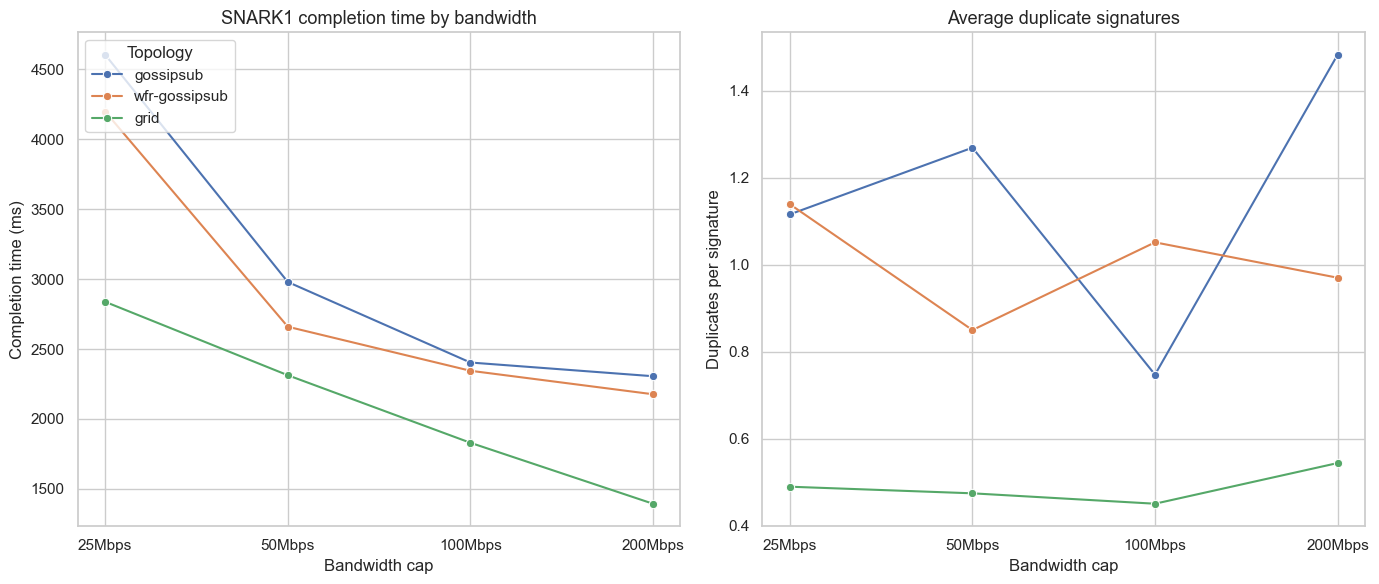

In [41]:
plot_df = combined_results_df[combined_results_df["error"].isna()].copy()
if not plot_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
    sns.lineplot(
        data=plot_df,
        x="bandwidth",
        y="snark1_completion_ms",
        hue="topology",
        marker="o",
        ax=axes[0],
    )
    axes[0].set_title("SNARK1 completion time by bandwidth")
    axes[0].set_ylabel("Completion time (ms)")
    axes[0].set_xlabel("Bandwidth cap")
    sns.lineplot(
        data=plot_df,
        x="bandwidth",
        y="duplicate_avg",
        hue="topology",
        marker="o",
        ax=axes[1],
    )
    axes[1].set_title("Average duplicate signatures")
    axes[1].set_ylabel("Duplicates per signature")
    axes[1].set_xlabel("Bandwidth cap")
    axes[0].legend(title="Topology", loc="upper left")
    axes[1].legend().remove()
    plt.tight_layout()
else:
    print("No successful runs to visualize.")